<a href="https://www.kaggle.com/code/nicolasfalcone/svm-previsao-de-precos-de-imoveis?scriptVersionId=354541184" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# SVM para Regressão: Previsão de Preços de Imóveis

**Aluno(a):** NOME SOBRENOME  
**Disciplina:** Aprendizado de Máquina  
**Algoritmo:** SVR (Support Vector Regression) — scikit-learn  
**Banco de dados:** Housing — Kaggle (`kathuman/housing`)  
**Meta:** R² > 0,65 no conjunto de teste

---

## Objetivo

Construir um modelo SVR capaz de prever o preço de imóveis, avaliando o impacto de cada etapa de tratamento dos dados (valores ausentes, outliers, padronização e otimização de hiperparâmetros) sobre o R² obtido no **conjunto de teste**.

## 0. Importação das bibliotecas

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

In [2]:
import os
for raiz, _, arquivos in os.walk("/kaggle/input"):
    for nome in arquivos:
        print(os.path.join(raiz, nome))

/kaggle/input/datasets/kathuman/housing/housing.csv


## 1. Carregamento dos dados

In [3]:
# Ajuste o caminho/nome do arquivo conforme o download do Kaggle
df = pd.read_csv("/kaggle/input/datasets/kathuman/housing/housing.csv")

print(df.head())
print()
print("Shape:", df.shape)
print()
df.info()

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -122.2300   37.8800             41.0000     880.0000        129.0000   
1  -122.2200   37.8600             21.0000   7,099.0000      1,106.0000   
2  -122.2400   37.8500             52.0000   1,467.0000        190.0000   
3  -122.2500   37.8500             52.0000   1,274.0000        235.0000   
4  -122.2500   37.8500             52.0000   1,627.0000        280.0000   

   population  households  median_income  median_house_value ocean_proximity  
0    322.0000    126.0000         8.3252        452,600.0000        NEAR BAY  
1  2,401.0000  1,138.0000         8.3014        358,500.0000        NEAR BAY  
2    496.0000    177.0000         7.2574        352,100.0000        NEAR BAY  
3    558.0000    219.0000         5.6431        341,300.0000        NEAR BAY  
4    565.0000    259.0000         3.8462        342,200.0000        NEAR BAY  

Shape: (20640, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2064

In [4]:
# Definição automática da variável alvo (preço do imóvel).
# Se o seu arquivo usar outro nome, basta escrever aqui: TARGET = "nome_da_coluna"
CANDIDATOS = ["price", "Price", "median_house_value", "SalePrice", "MEDV"]
TARGET = next((c for c in CANDIDATOS if c in df.columns), None)

if TARGET is None:
    raise ValueError(f"Defina TARGET manualmente. Colunas disponíveis: {list(df.columns)}")

print("Variável alvo:", TARGET)

Variável alvo: median_house_value


## 2. Etapa 1 — Conhecendo o banco de dados

### 2.1 Dimensões

In [5]:
linhas, colunas = df.shape
print(f"Quantidade de linhas (registros): {linhas}")
print(f"Quantidade de colunas (atributos): {colunas}")

Quantidade de linhas (registros): 20640
Quantidade de colunas (atributos): 10


### 2.2 Tipos de dados

In [6]:
df.info()
print()
print(df.dtypes.value_counts())

cols_int   = df.select_dtypes(include="int").columns.tolist()
cols_float = df.select_dtypes(include="float").columns.tolist()
cols_cat   = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nint    :", cols_int)
print("float  :", cols_float)
print("object :", cols_cat)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

float64    9
object     1
Name: count, dtype: int64

int    : []
float  : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
object : ['ocean_proximity']

**Comentário:** o banco possui **X linhas** e **Y colunas**. As colunas numéricas são ... (int/float) e as categóricas são ... (object). A variável alvo é `TARGET`, do tipo numérico contínuo, o que caracteriza um problema de **regressão**.

*(Substitua X, Y e as listas pelos valores que apareceram na saída acima.)*

### 2.3 Estatísticas descritivas

In [7]:
desc = df.describe().T
desc["coef_variacao"] = desc["std"] / desc["mean"]   # dispersão relativa
display(desc)

,count,mean,std,min,25%,50%,75%,max,coef_variacao
longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100,-0.0168
latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500,0.0599
housing_median_age,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000,0.4394
total_rooms,"20,640.0000","2,635.7631","2,181.6153",2.0000,"1,447.7500","2,127.0000","3,148.0000","39,320.0000",0.8277
total_bedrooms,"20,433.0000",537.8706,421.3851,1.0000,296.0000,435.0000,647.0000,"6,445.0000",0.7834
population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000",0.7944
households,"20,640.0000",499.5397,382.3298,1.0000,280.0000,409.0000,605.0000,"6,082.0000",0.7654
median_income,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001,0.4908
median_house_value,"20,640.0000","206,855.8169","115,395.6159","14,999.0000","119,600.0000","179,700.0000","264,725.0000","500,001.0000",0.5579


**Análise das estatísticas descritivas** *(complete com os números da tabela acima)*:

- **Maior dispersão:** as variáveis ... apresentam o maior desvio-padrão / coeficiente de variação.
- **Valores muito altos:** a diferença entre a mediana (50%) e o máximo em ... indica assimetria à direita e possível presença de valores extremos.
- **Valores mínimos/máximos estranhos:** ... (ex.: valor mínimo igual a zero, máximo muito distante do 75%, valor máximo repetido/truncado no alvo).
- **Escalas muito diferentes:** as variáveis estão em escalas muito distintas, o que reforça a necessidade de **padronização** antes do SVR.
- **Relação com o preço:** (ver seção de correlação) as variáveis ... parecem mais relacionadas ao preço.

### 2.4 Valores ausentes e duplicados

In [8]:
nulos = df.isnull().sum()
tabela_nulos = pd.DataFrame({"nulos": nulos, "percentual (%)": nulos / len(df) * 100})
display(tabela_nulos[tabela_nulos["nulos"] > 0] if nulos.sum() > 0 else tabela_nulos)

print("Total de valores ausentes:", int(nulos.sum()))
print("Registros duplicados:", df.duplicated().sum())

,nulos,percentual (%)
total_bedrooms,207,1.0029


Total de valores ausentes: 207
Registros duplicados: 0


**Decisão sobre os valores ausentes** *(ajuste conforme o resultado acima)*:

- Se **não houver** valores ausentes: o banco está completo e nenhum tratamento é necessário (o código está preparado caso apareçam).
- Se **houver** (ex.: `total_bedrooms`): serão **preenchidos pela mediana**, calculada **apenas no conjunto de treino** (evita vazamento de dados). A mediana foi escolhida em vez da média porque a variável é assimétrica e possui valores extremos, e a mediana é robusta a eles. Remover os registros faria perder dados sem necessidade, pois o percentual de ausentes é pequeno.
- Se houver registros **duplicados**, serão removidos (duplicatas contam duas vezes o mesmo imóvel e podem vazar entre treino e teste).

## 3. Etapa 2 — Análise exploratória

### Gráfico 1 — Distribuição da variável alvo

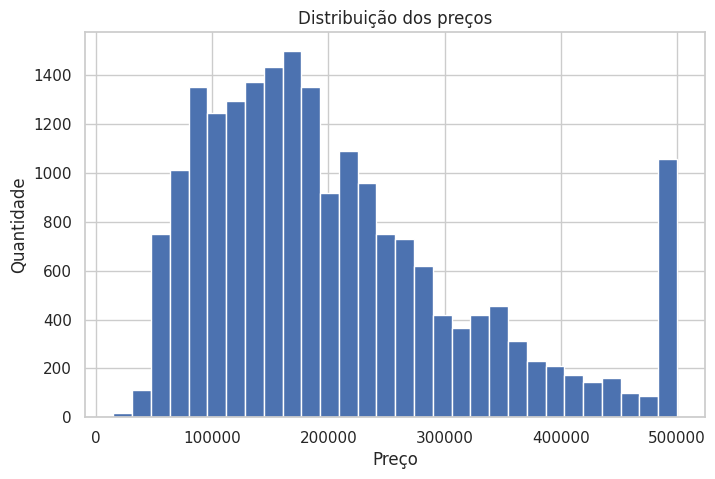

Assimetria (skew) do alvo: 0.978


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET].dropna(), bins=30, edgecolor="white")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Distribuição dos preços")
plt.show()

print("Assimetria (skew) do alvo:", round(df[TARGET].skew(), 3))

**Interpretação:** a distribuição dos preços é (assimétrica à direita / aproximadamente simétrica), com concentração de imóveis na faixa de ... e uma cauda de imóveis mais caros. *(Se houver um pico isolado no valor máximo, comente que o alvo pode estar truncado/limitado nesse valor.)*

### Gráfico 2 — Boxplots

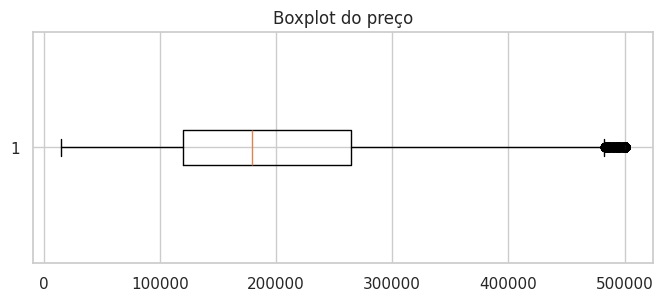

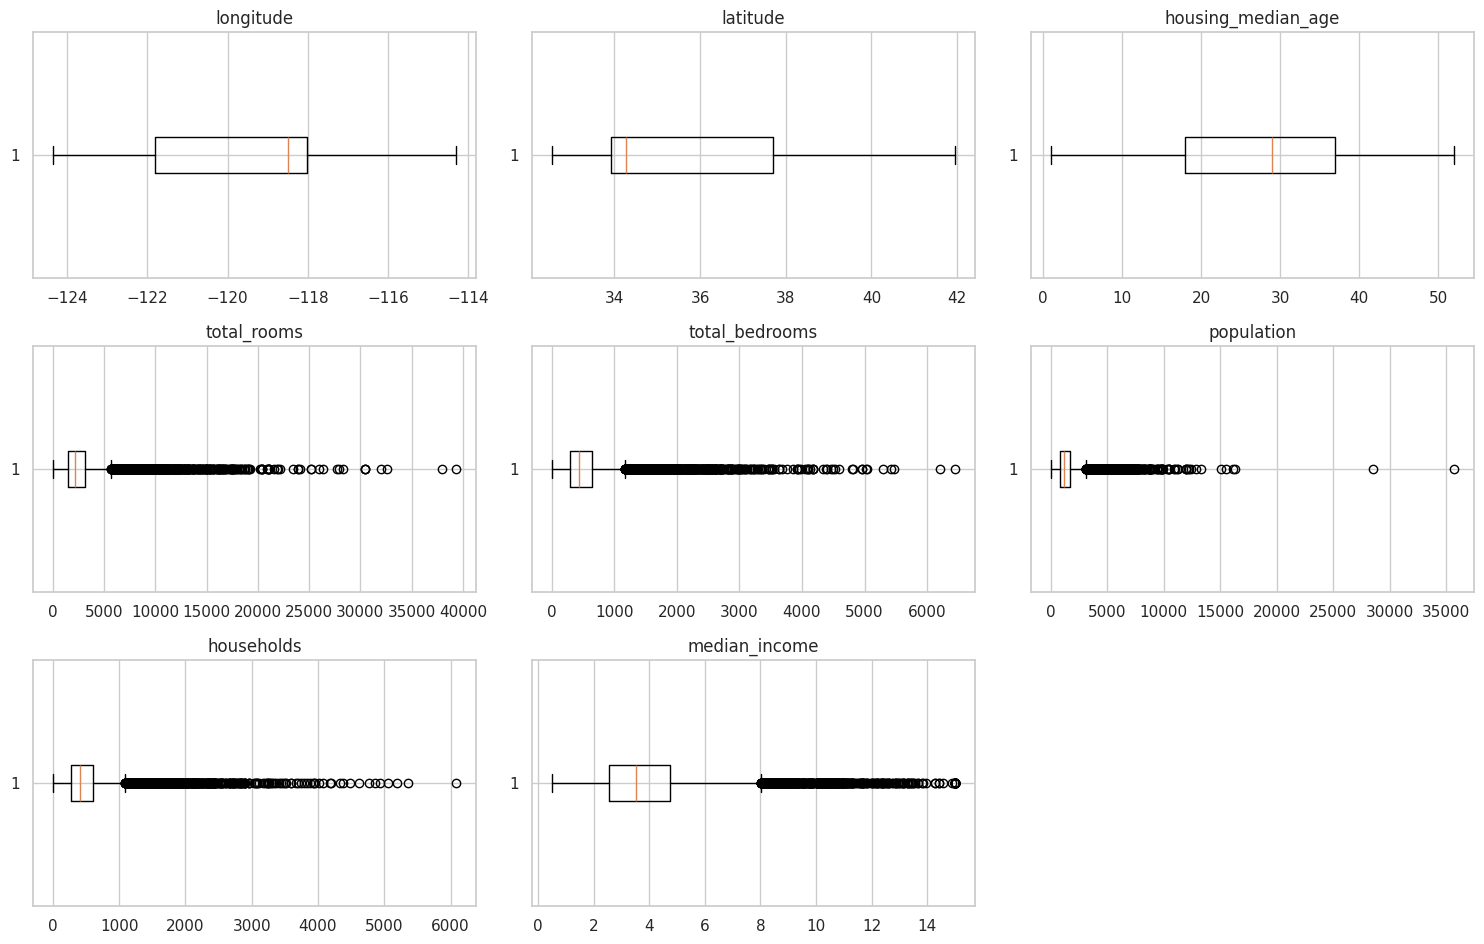

In [10]:
num_cols  = df.select_dtypes(include=np.number).columns.tolist()
cont_cols = [c for c in num_cols if df[c].nunique() > 2]   # ignora colunas binárias

# Boxplot do alvo
plt.figure(figsize=(8, 3))
plt.boxplot(df[TARGET].dropna(), vert=False)
plt.title("Boxplot do preço")
plt.show()

# Boxplot das demais variáveis numéricas
outras = [c for c in cont_cols if c != TARGET]
n = len(outras)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = np.array(axes).reshape(-1)
for ax, c in zip(axes, outras):
    ax.boxplot(df[c].dropna(), vert=False)
    ax.set_title(c)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Interpretação:** os boxplots mostram pontos além dos "bigodes" nas variáveis ..., indicando possíveis outliers (valores extremos). Isso será investigado de forma quantitativa na Etapa 3.

### Gráfico 3 — Correlação

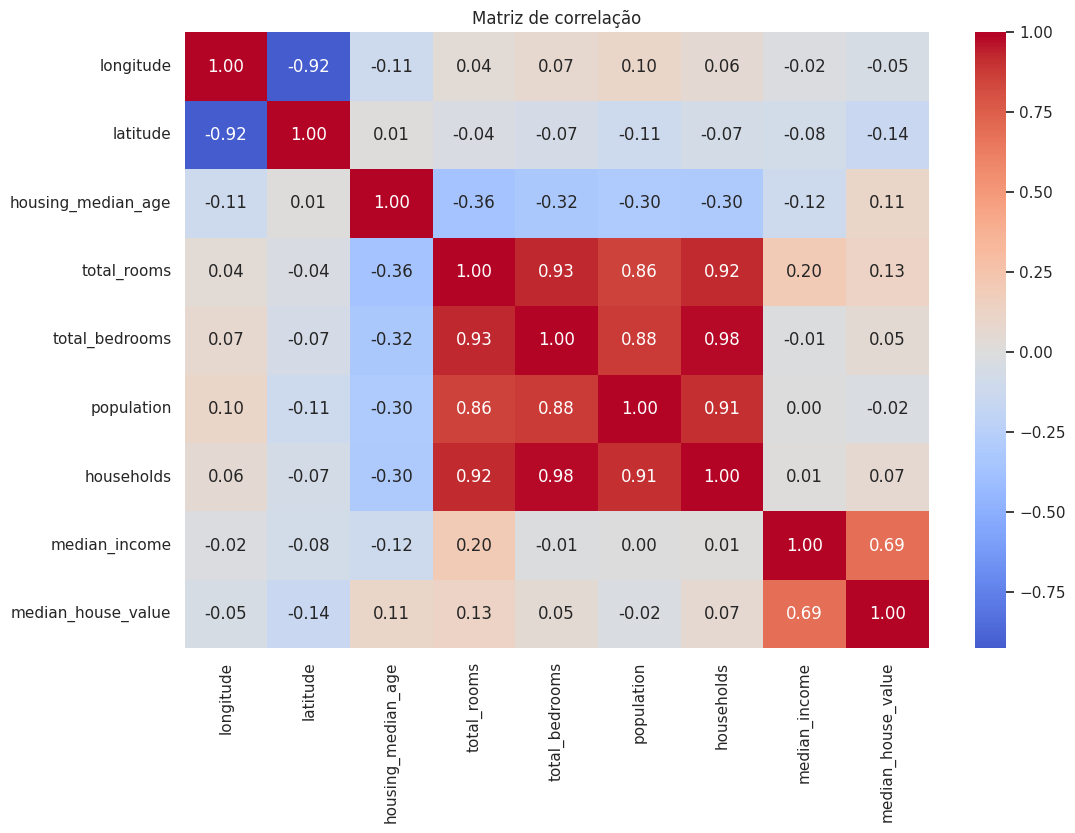

Correlação com o preço (ordenada):


,correlação
median_income,0.6881
total_rooms,0.1342
housing_median_age,0.1056
households,0.0658
total_bedrooms,0.0497
population,-0.0246
longitude,-0.0460
latitude,-0.1442


In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Matriz de correlação")
plt.show()

print("Correlação com o preço (ordenada):")
display(df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False).to_frame("correlação"))

**Interpretação da correlação** *(complete com o resultado)*:

- **Mais correlacionadas com o preço:** ... (correlação de ...).
- **Pouco relacionadas:** ... (correlação próxima de zero).
- **Possíveis variáveis redundantes:** pares com correlação muito alta entre si (ex.: ... e ...), que carregam informação parecida. Essa redundância não impede o SVR, mas pode ser explorada na seleção de atributos (desafio extra).

## 4. Etapa 3 — Identificação de outliers

**Método:** IQR (Intervalo Interquartil), com limites `Q1 − 1,5·IQR` e `Q3 + 1,5·IQR`. Os outliers são **apenas identificados** nesta etapa, sem remoção.

In [12]:
def relatorio_iqr(dados, colunas):
    """Identifica outliers pelo método IQR para cada coluna."""
    linhas = []
    for c in colunas:
        s = dados[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (s < lim_inf) | (s > lim_sup)
        linhas.append({
            "variavel": c,
            "metodo": "IQR (1.5)",
            "n_outliers": int(mask.sum()),
            "pct_outliers": mask.mean() * 100,
            "minimo": s.min(),
            "maximo": s.max(),
            "limite_inferior": lim_inf,
            "limite_superior": lim_sup,
            "menor_outlier": s[mask].min() if mask.any() else np.nan,
            "maior_outlier": s[mask].max() if mask.any() else np.nan,
        })
    return pd.DataFrame(linhas).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

rel_outliers = relatorio_iqr(df, cont_cols)
display(rel_outliers)

,variavel,metodo,n_outliers,pct_outliers,minimo,maximo,limite_inferior,limite_superior,menor_outlier,maior_outlier
0,total_rooms,IQR (1.5),1287,6.2355,2.0000,"39,320.0000","-1,102.6250","5,698.3750","5,699.0000","39,320.0000"
1,total_bedrooms,IQR (1.5),1271,6.2203,1.0000,"6,445.0000",-230.5000,"1,173.5000","1,174.0000","6,445.0000"
2,households,IQR (1.5),1220,5.9109,1.0000,"6,082.0000",-207.5000,"1,092.5000","1,093.0000","6,082.0000"
3,population,IQR (1.5),1196,5.7946,3.0000,"35,682.0000",-620.0000,"3,132.0000","3,134.0000","35,682.0000"
4,median_house_value,IQR (1.5),1071,5.1890,"14,999.0000","500,001.0000","-98,087.5000","482,412.5000","482,700.0000","500,001.0000"
5,median_income,IQR (1.5),681,3.2994,0.4999,15.0001,-0.7064,8.0130,8.0137,15.0001
6,longitude,IQR (1.5),0,0.0000,-124.3500,-114.3100,-127.4850,-112.3250,NaN,NaN
7,latitude,IQR (1.5),0,0.0000,32.5400,41.9500,28.2600,43.3800,NaN,NaN
8,housing_median_age,IQR (1.5),0,0.0000,1.0000,52.0000,-10.5000,65.5000,NaN,NaN


In [13]:
# Exemplo: registros considerados outliers no alvo
Q1, Q3 = df[TARGET].quantile(0.25), df[TARGET].quantile(0.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers_alvo = df[(df[TARGET] < lim_inf) | (df[TARGET] > lim_sup)]
print(f"Alvo '{TARGET}': {len(outliers_alvo)} outliers ({len(outliers_alvo)/len(df)*100:.2f}%)")
print(f"Limites: [{lim_inf:,.2f} ; {lim_sup:,.2f}]")
display(outliers_alvo.head())

Alvo 'median_house_value': 1071 outliers (5.19%)
Limites: [-98,087.50 ; 482,412.50]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
89,-122.2700,37.8000,52.0000,249.0000,78.0000,396.0000,85.0000,1.2434,"500,001.0000",NEAR BAY
140,-122.1800,37.8100,30.0000,292.0000,38.0000,126.0000,52.0000,6.3624,"483,300.0000",NEAR BAY
459,-122.2500,37.8700,52.0000,609.0000,236.0000,"1,349.0000",250.0000,1.1696,"500,001.0000",NEAR BAY
489,-122.2500,37.8600,48.0000,"2,153.0000",517.0000,"1,656.0000",459.0000,3.0417,"489,600.0000",NEAR BAY
493,-122.2400,37.8600,52.0000,"1,668.0000",225.0000,517.0000,214.0000,7.8521,"500,001.0000",NEAR BAY


**Resultado da identificação** *(complete com a tabela acima)*:

As variáveis com maior quantidade de outliers pelo método IQR foram ... (X% dos registros), seguidas de ... Variáveis binárias foram desconsideradas, pois o IQR não faz sentido para elas.

## 5. Etapa 4 — Tratamento dos outliers

**Decisão (justificativa):** os outliers **não serão removidos**, para não perder dados nem descartar imóveis reais (casas muito grandes ou muito caras existem de fato no mercado). Em vez disso será aplicado **capping / winsorization** pelo IQR nas **variáveis independentes contínuas**, substituindo valores além dos limites pelo próprio limite. Dessa forma:

- nenhum registro é excluído (o tamanho do banco é preservado);
- o efeito de valores extremos sobre a escala e sobre o kernel RBF do SVR é reduzido;
- os limites são calculados **somente com o conjunto de treino** e aplicados ao teste, evitando vazamento de dados.

A **variável alvo (preço) é mantida sem alteração**, pois alterar o alvo mudaria o que o modelo é avaliado para prever.

O tratamento é aplicado dentro da função de preparação (seção 7), logo após a divisão treino/teste.

## 6. Etapas 5, 6 e 7 — Preparação, divisão treino/teste e padronização

A função abaixo reúne todo o pré-processamento, com chaves para ligar/desligar cada tratamento. Isso permite comparar os experimentos de forma justa:

1. remove registros sem alvo e (opcional) duplicados;
2. transforma variáveis categóricas em numéricas com `pd.get_dummies`;
3. **divide treino/teste (80/20, `random_state=42`)**;
4. (opcional) preenche ausentes com a **mediana do treino**;
5. (opcional) aplica **capping IQR** com limites do treino;
6. (opcional) aplica **StandardScaler**, ajustado (`fit`) **somente no treino**.

In [14]:
def preparar_dados(df, imputar=True, outliers=True, padronizar=True, remover_duplicados=True):
    """Pré-processamento completo. Retorna X_train, X_test, y_train, y_test (e o scaler)."""
    d = df.copy()
    if remover_duplicados:
        d = d.drop_duplicates()
    d = d.dropna(subset=[TARGET])

    # variáveis independentes / dependente + variáveis categóricas -> numéricas
    X = pd.get_dummies(d.drop(columns=[TARGET]), drop_first=True, dtype=float)
    y = d[TARGET].astype(float)

    # sem tratamento de ausentes: o SVR não aceita NaN, então apenas descartamos essas linhas
    if not imputar:
        ok = X.notna().all(axis=1)
        X, y = X[ok], y[ok]

    # divisão treino/teste ANTES de qualquer estatística aprendida
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE
    )

    # valores ausentes -> mediana do TREINO
    if imputar:
        mediana = X_train.median()
        X_train = X_train.fillna(mediana)
        X_test = X_test.fillna(mediana)

    # outliers -> capping pelo IQR (limites calculados no TREINO)
    if outliers:
        cont = [c for c in X_train.columns if X_train[c].nunique() > 2]
        q1, q3 = X_train[cont].quantile(0.25), X_train[cont].quantile(0.75)
        iqr = q3 - q1
        cont = [c for c in cont if iqr[c] > 0]          # evita colunas com IQR = 0
        li, ls = (q1 - 1.5 * iqr)[cont], (q3 + 1.5 * iqr)[cont]
        X_train = X_train.copy(); X_test = X_test.copy()
        X_train[cont] = X_train[cont].clip(lower=li, upper=ls, axis=1)
        X_test[cont] = X_test[cont].clip(lower=li, upper=ls, axis=1)

    # padronização -> fit SOMENTE no treino
    scaler = None
    if padronizar:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler


def metricas(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def treinar_avaliar(X_train, X_test, y_train, y_test,
                    kernel="rbf", C=1.0, epsilon=0.1, gamma="scale", y_padronizado=False):
    """Treina um SVR e avalia no CONJUNTO DE TESTE."""
    svr = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma)
    modelo = (TransformedTargetRegressor(regressor=svr, transformer=StandardScaler())
              if y_padronizado else svr)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    return modelo, y_pred, metricas(y_test, y_pred)


# Tabela onde todos os experimentos serão registrados
resultados = []
def registrar(exp, tratamento, kernel, C, epsilon, r2, modelo_nome=""):
    resultados.append({"Experimento": exp, "Modelo": modelo_nome, "Tratamento": tratamento,
                       "Kernel": kernel, "C": C, "Epsilon": epsilon, "R²": r2})

In [15]:
# Conferência da divisão e da padronização (tratamento completo)
X_train, X_test, y_train, y_test, scaler = preparar_dados(df)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Média das colunas no treino (≈0):", np.round(X_train.mean(axis=0)[:5], 3))
print("Desvio das colunas no treino (≈1):", np.round(X_train.std(axis=0)[:5], 3))

Treino: (16512, 12) | Teste: (4128, 12)
Média das colunas no treino (≈0): [ 0.  0. -0. -0.  0.]
Desvio das colunas no treino (≈1): [1. 1. 1. 1. 1.]


## 7. Etapa 8 — Primeiro modelo SVR (baseline)

Modelo básico `SVR()` com parâmetros padrão (kernel RBF, C=1, epsilon=0,1), treinado nos **dados sem tratamento** (apenas conversão das variáveis categóricas e descarte de linhas com NaN, que o SVR não aceita). Sem tratamento de outliers e sem padronização.

In [16]:
X_tr, X_te, y_tr, y_te, _ = preparar_dados(df, imputar=False, outliers=False,
                                           padronizar=False, remover_duplicados=False)
modelo, y_pred, m = treinar_avaliar(X_tr, X_te, y_tr, y_te)

print("R² baseline (teste):", round(m["R2"], 4))
registrar(1, "Dados originais (sem tratamento)", "rbf", 1, 0.1, m["R2"], "Baseline")

R² baseline (teste): -0.0546


**Comentário:** o baseline obteve R² = ... no teste. Esse valor baixo é esperado: o SVR é sensível à escala das variáveis e do alvo, e aqui os dados não foram padronizados nem tratados.

## 8. Etapas 11 e 12 — Experimentos e comparação antes/depois do tratamento

Cada experimento acrescenta **um** tratamento ao anterior, para medir o impacto isolado de cada um:

| Exp. | Tratamento acumulado |
|---|---|
| 1 | Nenhum (baseline, já executado) |
| 2 | + tratamento de valores ausentes (mediana) e duplicados |
| 3 | + tratamento de outliers (capping IQR) |
| 4 | + padronização das variáveis independentes (`StandardScaler`) |
| 5 | + padronização do alvo (parâmetros manuais) |

In [17]:
# Experimento 2 — + valores ausentes (mediana) e duplicados
X_tr, X_te, y_tr, y_te, _ = preparar_dados(df, imputar=True, outliers=False, padronizar=False)
_, _, m = treinar_avaliar(X_tr, X_te, y_tr, y_te, kernel="rbf", C=1, epsilon=0.1)
registrar(2, "Valores ausentes (mediana)", "rbf", 1, 0.1, m["R2"], "Modelo 2")
print("Exp. 2 — R²:", round(m["R2"], 4))

# Experimento 3 — + outliers (capping IQR)
X_tr, X_te, y_tr, y_te, _ = preparar_dados(df, imputar=True, outliers=True, padronizar=False)
_, _, m = treinar_avaliar(X_tr, X_te, y_tr, y_te, kernel="rbf", C=10, epsilon=0.1)
registrar(3, "Ausentes + outliers (capping)", "rbf", 10, 0.1, m["R2"], "Modelo 3")
print("Exp. 3 — R²:", round(m["R2"], 4))

# Experimento 4 — + padronização das variáveis independentes
X_tr, X_te, y_tr, y_te, _ = preparar_dados(df, imputar=True, outliers=True, padronizar=True)
_, _, m = treinar_avaliar(X_tr, X_te, y_tr, y_te, kernel="rbf", C=100, epsilon=0.1)
registrar(4, "Ausentes + outliers + padronização de X", "rbf", 100, 0.1, m["R2"], "Modelo 4")
print("Exp. 4 — R²:", round(m["R2"], 4))

# Experimento 5 — + padronização do alvo (epsilon passa a estar na mesma escala do alvo)
_, _, m = treinar_avaliar(X_tr, X_te, y_tr, y_te, kernel="rbf", C=10, epsilon=0.1, y_padronizado=True)
registrar(5, "Tratamento completo + padronização de y", "rbf", 10, 0.1, m["R2"], "Modelo 4b")
print("Exp. 5 — R²:", round(m["R2"], 4))

Exp. 2 — R²: -0.0487
Exp. 3 — R²: -0.0371
Exp. 4 — R²: 0.3405
Exp. 5 — R²: 0.7682


**Comentário:** o tratamento de ... foi o que mais elevou o R². O tratamento de outliers (Exp. 2 → 3) (melhorou / teve pouco efeito). A padronização (Exp. 3 → 4) ... O alvo, por estar em uma escala muito grande, faz com que o parâmetro `epsilon` e o `C` do SVR tenham efeito diferente do esperado; padronizá-lo (Exp. 5) ...

### 8.1 Comparação de kernels (Etapa 9 — item 11.1)

Dados com tratamento completo (ausentes + outliers + padronização de X), parâmetros padrão (C=1, epsilon=0,1), comparando `linear`, `rbf` e `poly`. Testado com o alvo original e com o alvo padronizado.

> ⏳ Em bancos grandes (milhares de linhas) esta célula pode levar alguns minutos.

In [18]:
X_tr, X_te, y_tr, y_te, _ = preparar_dados(df, imputar=True, outliers=True, padronizar=True)

linhas_kernel = []
for kernel in ["linear", "rbf", "poly"]:
    _, _, m_orig = treinar_avaliar(X_tr, X_te, y_tr, y_te, kernel=kernel)
    _, _, m_pad  = treinar_avaliar(X_tr, X_te, y_tr, y_te, kernel=kernel, y_padronizado=True)
    linhas_kernel.append({"Kernel": kernel, "R² (alvo original)": m_orig["R2"],
                          "R² (alvo padronizado)": m_pad["R2"]})
    print(f"{kernel:7s} -> original: {m_orig['R2']:.4f} | alvo padronizado: {m_pad['R2']:.4f}")

tabela_kernels = pd.DataFrame(linhas_kernel)
display(tabela_kernels)

linear  -> original: 0.1186 | alvo padronizado: 0.6158
rbf     -> original: -0.0425 | alvo padronizado: 0.7489
poly    -> original: -0.0401 | alvo padronizado: 0.6819


,Kernel,R² (alvo original),R² (alvo padronizado)
0,linear,0.1186,0.6158
1,rbf,-0.0425,0.7489
2,poly,-0.0401,0.6819


**Comentário:** o kernel que apresentou o melhor R² foi o ... O kernel linear só captura relações lineares entre as variáveis e o preço; o RBF modela relações não lineares (por isso costuma ir melhor em preços de imóveis); o polinomial (grau 3) pode superajustar e é mais sensível à escala.

## 9. Etapa 10 — Otimização dos hiperparâmetros (GridSearchCV)

Para a busca, usa-se um `Pipeline` com `StandardScaler` + `SVR`, embrulhado em `TransformedTargetRegressor` (que padroniza o alvo). Assim, **dentro de cada fold da validação cruzada**, o scaler é ajustado apenas nos dados de treino do fold — sem vazamento. A busca usa **somente o conjunto de treino**; o teste só é usado na avaliação final.

Se o banco for grande (> 3000 registros), é usada uma busca aleatória reduzida (`RandomizedSearchCV`, 3 folds) para o tempo de execução ser viável; caso contrário, é usado o `GridSearchCV` completo (5 folds) com a grade sugerida na atividade.

In [19]:
# Dados tratados (ausentes + outliers), SEM padronizar: o scaler fica dentro do Pipeline
X_tr, X_te, y_tr, y_te, _ = preparar_dados(df, imputar=True, outliers=True, padronizar=False)

pipe = TransformedTargetRegressor(
    regressor=Pipeline([("scaler", StandardScaler()), ("svr", SVR())]),
    transformer=StandardScaler()
)

if len(X_tr) <= 3000:
    parametros = {
        "regressor__svr__C": [0.1, 1, 10, 100, 1000],
        "regressor__svr__epsilon": [0.01, 0.1, 0.2, 0.5],
        "regressor__svr__gamma": ["scale", "auto"],
        "regressor__svr__kernel": ["rbf", "linear"],
    }
    busca = GridSearchCV(pipe, parametros, cv=5, scoring="r2", n_jobs=-1, verbose=1)
else:
    parametros = {
        "regressor__svr__C": [1, 10, 100, 1000],
        "regressor__svr__epsilon": [0.01, 0.1, 0.2],
        "regressor__svr__gamma": ["scale", "auto", 0.05, 0.2],
        "regressor__svr__kernel": ["rbf"],
    }
    busca = RandomizedSearchCV(pipe, parametros, n_iter=12, cv=3, scoring="r2",
                               n_jobs=-1, random_state=RANDOM_STATE, verbose=1)

busca.fit(X_tr, y_tr)

print("Melhores parâmetros:", busca.best_params_)
print("Melhor R² na validação cruzada:", round(busca.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhores parâmetros: {'regressor__svr__kernel': 'rbf', 'regressor__svr__gamma': 0.2, 'regressor__svr__epsilon': 0.1, 'regressor__svr__C': 10}
Melhor R² na validação cruzada: 0.7827


In [20]:
# Resultado de todas as combinações testadas (top 10)
cv = pd.DataFrame(busca.cv_results_)
cols = [c for c in cv.columns if c.startswith("param_")] + ["mean_test_score", "std_test_score"]
display(cv[cols].sort_values("mean_test_score", ascending=False).head(10))

,param_regressor__svr__kernel,param_regressor__svr__gamma,param_regressor__svr__epsilon,param_regressor__svr__C,mean_test_score,std_test_score
7,rbf,0.2000,0.1000,10,0.7827,0.0032
4,rbf,scale,0.0100,100,0.7799,0.0040
9,rbf,auto,0.0100,100,0.7799,0.0040
2,rbf,0.0500,0.0100,100,0.7787,0.0019
6,rbf,scale,0.0100,10,0.7766,0.0022
11,rbf,0.2000,0.0100,1,0.7709,0.0031
1,rbf,scale,0.1000,1000,0.7631,0.0049
10,rbf,scale,0.2000,1,0.7596,0.0030
8,rbf,scale,0.1000,1,0.7589,0.0030
5,rbf,auto,0.0100,1000,0.7569,0.0053


## 10. Etapa 13 — Avaliação final no conjunto de teste

O R² abaixo é calculado com `r2_score(y_test, y_pred)`, ou seja, **em dados que não foram usados no treinamento** (requisito da atividade).

In [21]:
modelo_final = busca.best_estimator_
y_pred = modelo_final.predict(X_te)

final = metricas(y_te, y_pred)
print(f"R²   (teste): {final['R2']:.4f}")
print(f"MAE  (teste): {final['MAE']:,.2f}")
print(f"RMSE (teste): {final['RMSE']:,.2f}")
print()
print("Meta atingida (R² > 0,65)!" if final["R2"] > 0.65 else "Meta NÃO atingida — veja o desafio extra abaixo.")

bp = busca.best_params_
registrar(6, "Tratamento completo + otimização (busca)", bp["regressor__svr__kernel"],
          bp["regressor__svr__C"], bp["regressor__svr__epsilon"], final["R2"], "Modelo final")

R²   (teste): 0.7723
MAE  (teste): 35,745.75
RMSE (teste): 54,620.32

Meta atingida (R² > 0,65)!


**Interpretação:** o modelo final explica cerca de ...% da variabilidade dos preços no conjunto de teste (R² = ...). O **MAE** indica que, em média, o modelo erra cerca de ... unidades monetárias por imóvel; o **RMSE**, por penalizar mais os erros grandes, é maior que o MAE, indicando que existem alguns imóveis com erro de previsão elevado (tipicamente os mais caros).

## 11. Etapa 14 — Gráfico Real × Predito

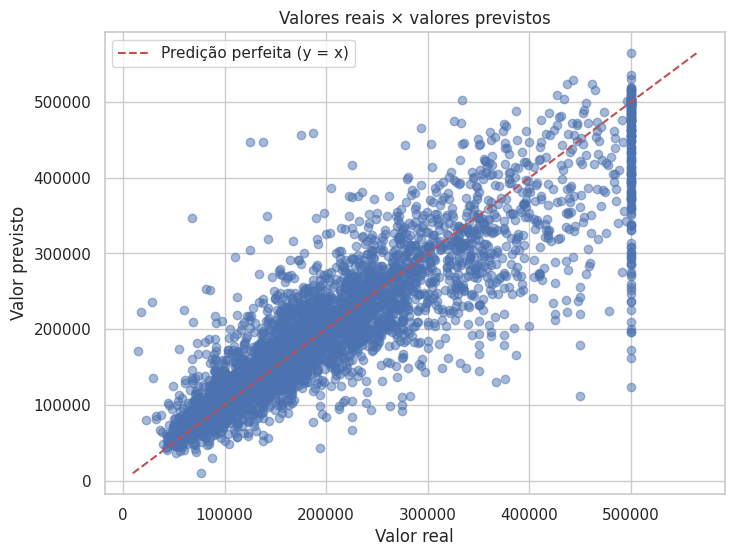

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_te, y_pred, alpha=0.5)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Predição perfeita (y = x)")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Valores reais × valores previstos")
plt.legend()
plt.show()

**Explicação do gráfico:** cada ponto é um imóvel do conjunto de teste. Quanto mais próximos os pontos estiverem da diagonal vermelha (y = x), mais próxima a previsão está do valor real. Observa-se que os pontos (se concentram em torno da diagonal / se afastam da diagonal nos preços mais altos), indicando que o modelo (subestima os imóveis mais caros, comportamento comum quando há poucos exemplos de preços elevados no treino).

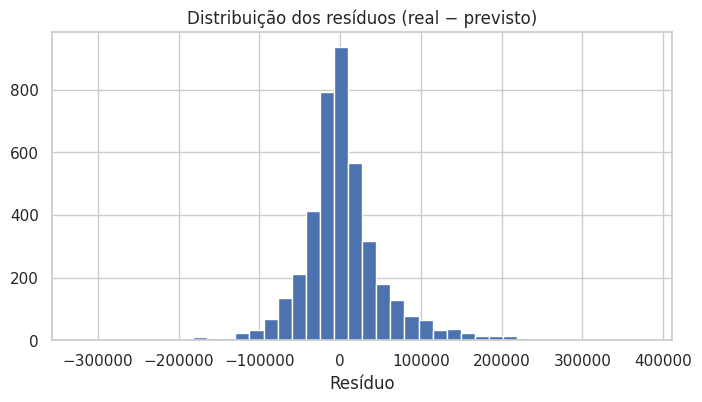

In [23]:
# Resíduos (opcional, ajuda na discussão)
residuos = y_te - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=40, edgecolor="white")
plt.title("Distribuição dos resíduos (real − previsto)")
plt.xlabel("Resíduo")
plt.show()

## 12. Tabelas de resultados

### Tabela de experimentos (Etapa 11)

In [24]:
tabela_exp = pd.DataFrame(resultados)[["Experimento", "Tratamento", "Kernel", "C", "Epsilon", "R²"]]
display(tabela_exp)

,Experimento,Tratamento,Kernel,C,Epsilon,R²
0,1,Dados originais (sem tratamento),rbf,1,0.1000,-0.0546
1,2,Valores ausentes (mediana),rbf,1,0.1000,-0.0487
2,3,Ausentes + outliers (capping),rbf,10,0.1000,-0.0371
3,4,Ausentes + outliers + padronização de X,rbf,100,0.1000,0.3405
4,5,Tratamento completo + padronização de y,rbf,10,0.1000,0.7682
5,6,Tratamento completo + otimização (busca),rbf,10,0.1000,0.7723


### Comparação antes e depois do tratamento (Etapa 12)

,Modelo,Tratamento,R²
0,Baseline,Dados originais (sem tratamento),-0.0546
1,Modelo 2,Valores ausentes (mediana),-0.0487
2,Modelo 3,Ausentes + outliers (capping),-0.0371
3,Modelo 4,Ausentes + outliers + padronização de X,0.3405
4,Modelo 4 (+ alvo padronizado),Tratamento completo + padronização de y,0.7682
5,Modelo final (otimização),Tratamento completo + otimização (busca),0.7723


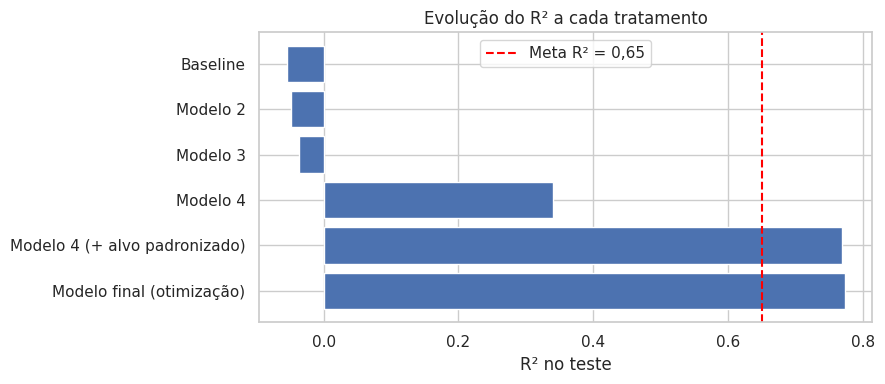

In [25]:
comparacao = pd.DataFrame(resultados)[["Modelo", "Tratamento", "R²"]].copy()
comparacao["Modelo"] = comparacao["Modelo"].replace({
    "Modelo 4b": "Modelo 4 (+ alvo padronizado)",
    "Modelo final": "Modelo final (otimização)"
})
display(comparacao)

plt.figure(figsize=(9, 4))
plt.barh(comparacao["Modelo"], comparacao["R²"])
plt.axvline(0.65, color="red", linestyle="--", label="Meta R² = 0,65")
plt.xlabel("R² no teste")
plt.gca().invert_yaxis()
plt.legend()
plt.title("Evolução do R² a cada tratamento")
plt.tight_layout()
plt.show()

## 13. Desafio extra (opcional)

Se o R² ainda estiver abaixo do desejado — ou para tentar melhorá-lo — duas ideias justificáveis:

1. **Transformação logarítmica do alvo**: preços são assimétricos à direita; `log1p` aproxima a distribuição de uma normal.
2. **Engenharia de atributos**: criar variáveis derivadas (ex.: razões entre colunas).

In [26]:
# Desafio extra 1: log do alvo, mantendo os melhores hiperparâmetros encontrados
bp = busca.best_params_
pipe_log = TransformedTargetRegressor(
    regressor=Pipeline([("scaler", StandardScaler()),
                        ("svr", SVR(kernel=bp["regressor__svr__kernel"],
                                    C=bp["regressor__svr__C"],
                                    epsilon=bp["regressor__svr__epsilon"],
                                    gamma=bp["regressor__svr__gamma"]))]),
    func=np.log1p, inverse_func=np.expm1
)
pipe_log.fit(X_tr, y_tr)
m_log = metricas(y_te, pipe_log.predict(X_te))
print("R² com log1p no alvo:", round(m_log["R2"], 4), "| R² anterior:", round(final["R2"], 4))
print("MAE:", round(m_log["MAE"], 2), "| RMSE:", round(m_log["RMSE"], 2))

R² com log1p no alvo: 0.7536 | R² anterior: 0.7723
MAE: 35480.16 | RMSE: 56819.19


## 14. Conclusão

*(Complete com os números obtidos na sua execução.)*

- **O modelo atingiu R² > 0,65?** Sim/Não. O modelo final obteve R² = ... no conjunto de teste (calculado com `r2_score(y_test, y_pred)`).
- **Qual tratamento teve maior impacto?** ... (comparar as linhas da tabela de comparação; normalmente a **padronização** é a que mais impacta o SVR).
- **O tratamento de outliers melhorou o resultado?** ... (comparar Exp. 2 → Exp. 3). Foi usado capping pelo IQR, sem remover registros.
- **Qual kernel apresentou melhor resultado?** ... (ver seção 8.1 e a busca de hiperparâmetros).
- **Hiperparâmetros do modelo final:** kernel = ..., C = ..., epsilon = ..., gamma = ....
- **Dificuldades encontradas:** sensibilidade do SVR à escala; tempo de treinamento em bancos grandes (complexidade entre O(n²) e O(n³)); escolha do tratamento de outliers sem descartar imóveis reais; (alvo truncado no valor máximo, se aplicável).
- **O modelo poderia ser melhorado?** Sim: busca de hiperparâmetros mais ampla, seleção de atributos, engenharia de atributos (razões entre variáveis), transformação do alvo (log) e comparação com outros modelos (Random Forest, Gradient Boosting).